Run root: /scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260407_210830_v1_s1_50


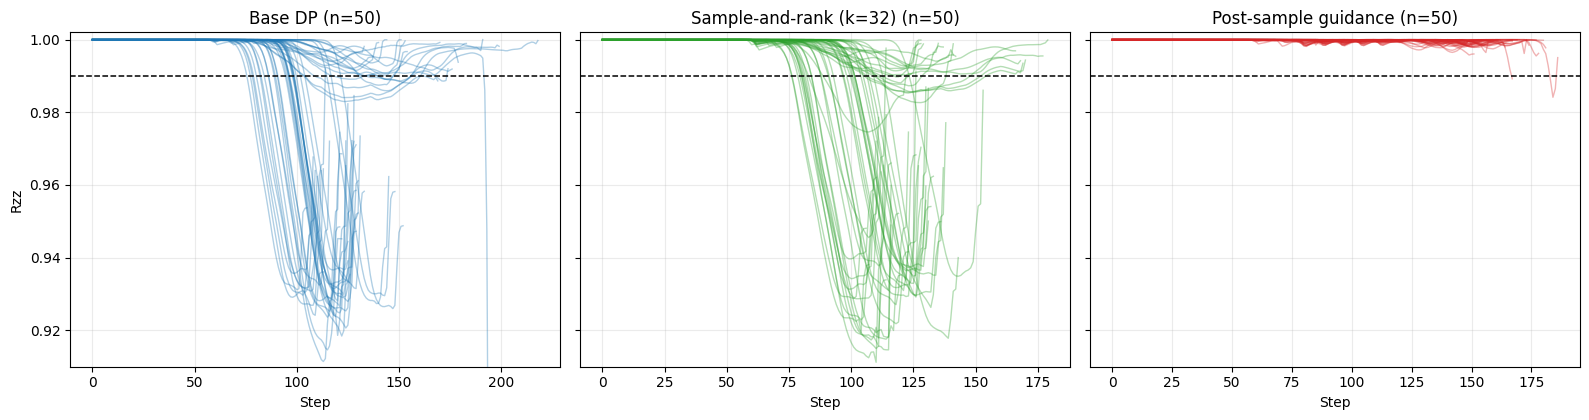


Method                N   Success %         Avg_Rzz (core)    Timestep_VFrac(core)
----------------------------------------------------------------------------------
DP                    50  100.00%           0.9904            0.1933              
SNR32                 50  +0.00% (100.00%)  -0.0001 (0.9903)  +0.0051 (0.1984)    
Post-sample guidance  50  +0.00% (100.00%)  +0.0094 (0.9998)  -0.1929 (0.0004)    


In [8]:
from pathlib import Path
import json
from typing import Dict, List

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Config
# ----------------------------
_RUN_ROOT_CANDIDATES = [
    Path("outputs/can_rollouts/comparison/20260407_210830_v1_s1_50"),
    Path("../outputs/can_rollouts/comparison/20260407_210830_v1_s1_50"),
]
RUN_ROOT = None
for candidate in _RUN_ROOT_CANDIDATES:
    resolved = candidate.resolve()
    if resolved.exists():
        RUN_ROOT = resolved
        break
if RUN_ROOT is None:
    raise FileNotFoundError(
        "Could not locate run root. Tried:\n"
        + "\n".join(str(c.resolve()) for c in _RUN_ROOT_CANDIDATES)
    )

RZZ_THRESHOLD = 0.99
PLOT_YMIN = 0.91
PLOT_YMAX = 1.002
METHODS = {
    "dp_base": "Base DP",
    "snr_k32": "Sample-and-rank (k=32)",
    "post_sample_guidance": "Post-sample guidance",
}
COLORS = {
    "dp_base": "#1f77b4",
    "snr_k32": "#2ca02c",
    "post_sample_guidance": "#d62728",
}

print(f"Run root: {RUN_ROOT}")


# ----------------------------
# Load helpers
# ----------------------------
def _read_jsonl(path: Path) -> List[dict]:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def _extract_seed_from_name(name: str):
    # Supports both ...__seed_01 and ..._seed1 naming styles.
    if "__seed_" in name:
        try:
            return int(name.split("__seed_")[-1])
        except ValueError:
            return None
    if "_seed" in name:
        tail = name.split("_seed")[-1]
        digits = "".join(ch for ch in tail if ch.isdigit())
        if digits:
            return int(digits)
    return None


def load_method_data(method_slug: str) -> Dict[str, object]:
    method_dir = RUN_ROOT / method_slug
    if not method_dir.exists():
        raise FileNotFoundError(f"Missing method directory: {method_dir}")

    # Prefer aggregated rows if available, otherwise build rows from per-seed stats.
    rows_path = method_dir / "rollout_rows.jsonl"
    if rows_path.exists():
        rows = _read_jsonl(rows_path)
    else:
        rows = []
        for seed_dir in sorted([p for p in method_dir.iterdir() if p.is_dir()]):
            stats_path = seed_dir / "rollout_stats.json"
            if stats_path.exists():
                with stats_path.open("r", encoding="utf-8") as f:
                    row = json.load(f)
                row.setdefault("seed", _extract_seed_from_name(seed_dir.name))
                row.setdefault("combo_dir", str(seed_dir.resolve()))
                rows.append(row)

    if not rows:
        raise RuntimeError(f"No rollout rows found for method {method_slug}")

    trajectories = {}
    for seed_dir in sorted([p for p in method_dir.iterdir() if p.is_dir()]):
        npz_path = seed_dir / "rollout_numeric.npz"
        if not npz_path.exists():
            continue
        seed = _extract_seed_from_name(seed_dir.name)
        if seed is None:
            continue
        data = np.load(npz_path, allow_pickle=True)
        if "rzz_mujoco" not in data.files:
            continue
        trajectories[seed] = np.asarray(data["rzz_mujoco"], dtype=float)

    return {"rows": rows, "trajectories": trajectories}


all_data = {slug: load_method_data(slug) for slug in METHODS.keys()}


# ----------------------------
# Plot: three method panels side-by-side, each showing all rollout lines
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3), sharey=True)
for ax, (slug, label) in zip(axes, METHODS.items()):
    traj_map = all_data[slug]["trajectories"]
    seeds = sorted(traj_map.keys())
    color = COLORS[slug]

    for seed in seeds:
        rzz = traj_map[seed]
        x = np.arange(len(rzz))
        ax.plot(x, rzz, color=color, linewidth=1.0, alpha=0.35)

    ax.axhline(RZZ_THRESHOLD, color="black", linestyle="--", linewidth=1.1)
    ax.set_ylim(PLOT_YMIN, PLOT_YMAX)
    ax.set_title(f"{label} (n={len(seeds)})")
    ax.set_xlabel("Step")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Rzz")
plt.tight_layout()
plt.show()


# ----------------------------
# Metrics: DP raw, others as delta (raw)
# ----------------------------
def compute_metrics(rows: List[dict]) -> Dict[str, float]:
    success = np.array([bool(r.get("success", False)) for r in rows], dtype=float)
    mean_rzz = np.array([float(r.get("mean_rzz", np.nan)) for r in rows], dtype=float)

    # Violation fraction = fraction of per-step rzz samples below threshold.
    violation_vals = []
    for r in rows:
        combo_dir = r.get("combo_dir")
        if not combo_dir:
            continue
        npz_path = Path(combo_dir) / "rollout_numeric.npz"
        if npz_path.exists():
            with np.load(npz_path, allow_pickle=True) as arrs:
                arr = arrs.get("rzz_mujoco", None)
                if arr is not None and len(arr) > 0:
                    arr = np.asarray(arr, dtype=float)
                    violation_vals.append(float(np.mean(arr < RZZ_THRESHOLD)))

    return {
        "success_rate": float(np.nanmean(success)) if len(success) else np.nan,
        "avg_rzz": float(np.nanmean(mean_rzz)) if len(mean_rzz) else np.nan,
        "violation_fraction": float(np.nanmean(violation_vals)) if violation_vals else np.nan,
        "num_rollouts": int(len(rows)),
    }


metrics = {slug: compute_metrics(all_data[slug]["rows"]) for slug in METHODS.keys()}
base = metrics["dp_base"]


def _fmt_raw(x: float) -> str:
    return "nan" if np.isnan(x) else f"{x:.4f}"


def _fmt_pct_raw(x: float) -> str:
    return "nan" if np.isnan(x) else f"{100.0 * x:.2f}%"


def _fmt_delta_raw(x: float, raw: float) -> str:
    if np.isnan(x) or np.isnan(raw):
        return "nan"
    return f"{x:+.4f} ({raw:.4f})"


def _fmt_pct_delta_raw(x: float, raw: float) -> str:
    if np.isnan(x) or np.isnan(raw):
        return "nan"
    return f"{100.0 * x:+.2f}% ({100.0 * raw:.2f}%)"


method_names = {
    "dp_base": "DP",
    "snr_k32": "SNR32",
    "post_sample_guidance": "Post-sample guidance",
}

headers = [
    "Method",
    "N",
    "Success %",
    "Avg_Rzz (core)",
    "Timestep_VFrac(core)",
]

table_rows = []
for slug in METHODS.keys():
    m = metrics[slug]
    if slug == "dp_base":
        row = [
            method_names[slug],
            str(m["num_rollouts"]),
            _fmt_pct_raw(m["success_rate"]),
            _fmt_raw(m["avg_rzz"]),
            _fmt_raw(m["violation_fraction"]),
        ]
    else:
        row = [
            method_names[slug],
            str(m["num_rollouts"]),
            _fmt_pct_delta_raw(m["success_rate"] - base["success_rate"], m["success_rate"]),
            _fmt_delta_raw(m["avg_rzz"] - base["avg_rzz"], m["avg_rzz"]),
            _fmt_delta_raw(m["violation_fraction"] - base["violation_fraction"], m["violation_fraction"]),
        ]
    table_rows.append(row)

widths = [
    max(len(headers[i]), *(len(r[i]) for r in table_rows))
    for i in range(len(headers))
]

print("")
header_line = "  ".join(headers[i].ljust(widths[i]) for i in range(len(headers)))
print(header_line)
print("-" * len(header_line))
for row in table_rows:
    print("  ".join(row[i].ljust(widths[i]) for i in range(len(headers))))

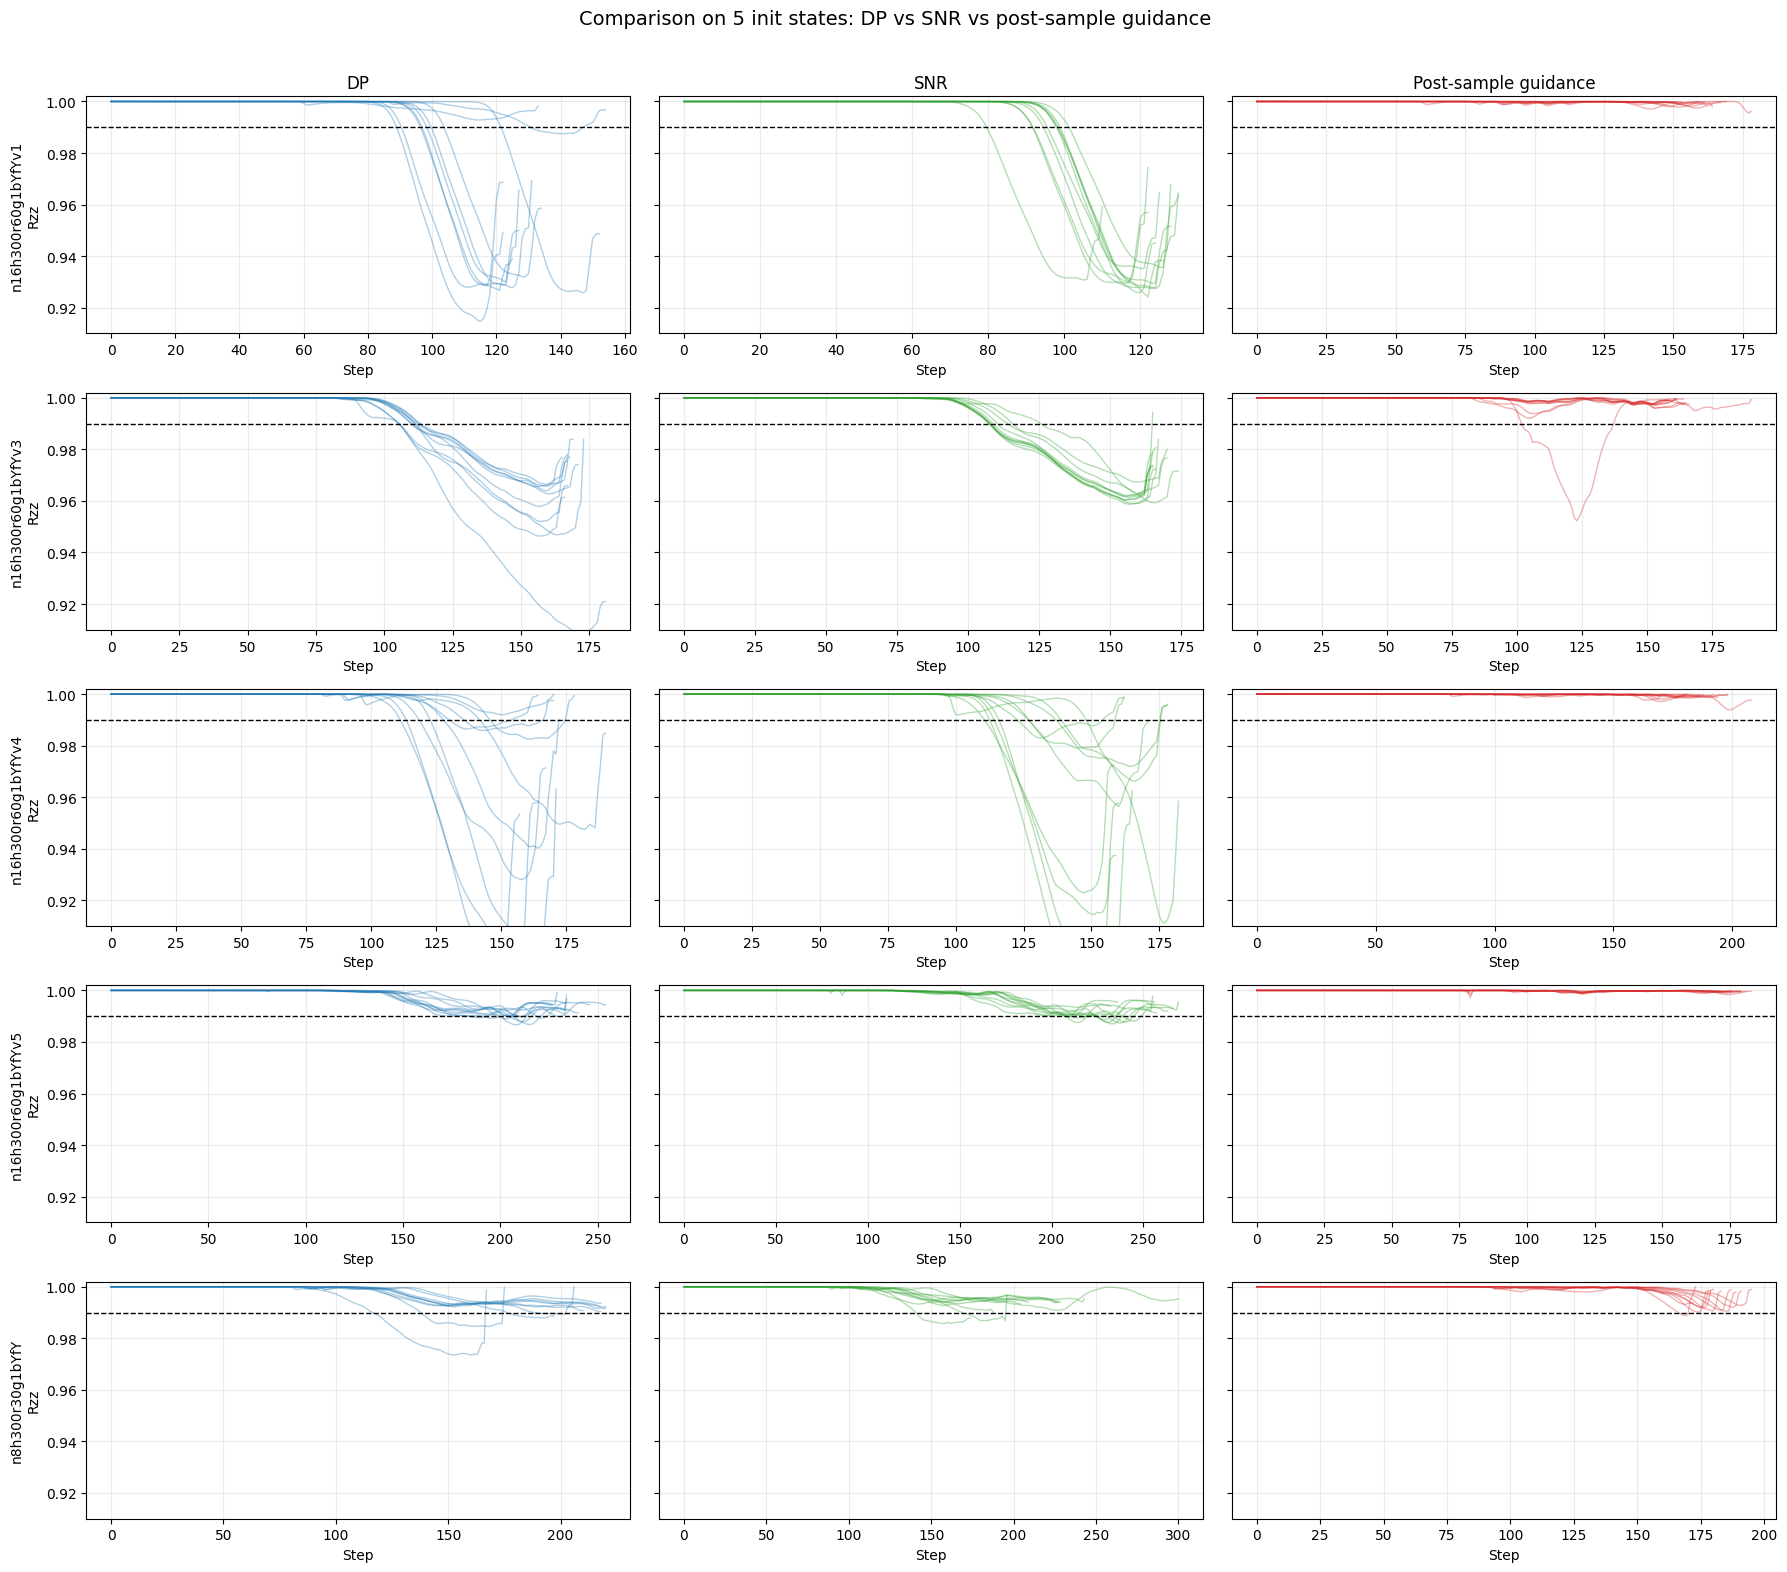


Init state: n16h300r60g1bYfYv1
Method                N   Success %         Avg_Rzz (core)    Timestep_VFrac(core)
----------------------------------------------------------------------------------
DP                    10  100.00%           0.9895            0.2013              
SNR                   10  +0.00% (100.00%)  -0.0018 (0.9877)  +0.0407 (0.2420)    
Post-sample guidance  10  +0.00% (100.00%)  +0.0103 (0.9998)  -0.2013 (0.0000)    

Init state: n16h300r60g1bYfYv3
Method                N   Success %         Avg_Rzz (core)    Timestep_VFrac(core)
----------------------------------------------------------------------------------
DP                    10  100.00%           0.9881            0.3539              
SNR                   10  +0.00% (100.00%)  +0.0025 (0.9906)  -0.0173 (0.3366)    
Post-sample guidance  10  +0.00% (100.00%)  +0.0107 (0.9988)  -0.3351 (0.0188)    

Init state: n16h300r60g1bYfYv4
Method                N   Success %         Avg_Rzz (core)    Timestep_VFr

In [15]:
from pathlib import Path
import json
from typing import Dict, List

import numpy as np
import matplotlib.pyplot as plt

comparison_root = None
for candidate in [
    Path("outputs/can_rollouts/comparison/20260404_171101"),
    Path("../outputs/can_rollouts/comparison/20260404_171101"),
]:
    resolved = candidate.resolve()
    if resolved.exists():
        comparison_root = resolved
        break
if comparison_root is None:
    raise FileNotFoundError("Could not locate comparison root for 20260404_171101")

plot_threshold = 0.99
metric_threshold = 0.99

init_state_rows = [
    (0, "init_state_seed0", "n16h300r60g1bYfYv1"),
    (1, "init_state_seed1", "n16h300r60g1bYfYv3"),
    (2, "init_state_seed2", "n16h300r60g1bYfYv4"),
    (3, "init_state_seed3", "n16h300r60g1bYfYv5"),
    (4, "init_state_seed4", "n8h300r30g1bYfY"),
]
method_specs = [
    ("dp_base", "DP", "#1f77b4", "flat"),
    ("snr_k8", "SNR", "#2ca02c", "flat"),
    ("post_sample_guidance", "Post-sample guidance", "#d62728", "nested"),
]
method_display = {
    "dp_base": "DP",
    "snr_k8": "SNR",
    "post_sample_guidance": "Post-sample guidance",
}


def load_rzz_series(npz_path: Path) -> np.ndarray:
    with np.load(npz_path, allow_pickle=True) as data:
        return np.asarray(data["rzz_mujoco"], dtype=np.float32)


def load_method_rows(method_slug: str, init_state_folder: str, init_name: str, folder_mode: str) -> List[dict]:
    method_dir = comparison_root / method_slug
    if folder_mode == "nested":
        init_dir = method_dir / init_state_folder
        seed_dirs = sorted([p for p in init_dir.iterdir() if p.is_dir() and "__seed_" in p.name]) if init_dir.exists() else []
    else:
        seed_dirs = sorted(method_dir.glob(f"{init_name}__seed_*"))

    rows = []
    for seed_dir in seed_dirs:
        stats_path = seed_dir / "rollout_stats.json"
        npz_path = seed_dir / "rollout_numeric.npz"
        if not stats_path.exists() or not npz_path.exists():
            continue
        with stats_path.open("r", encoding="utf-8") as f:
            stats = json.load(f)
        rzz = load_rzz_series(npz_path)
        rows.append(
            {
                "seed": int(stats.get("seed", -1)),
                "success": bool(stats.get("success", False)),
                "mean_rzz": float(stats.get("mean_rzz", np.mean(rzz))),
                "violation_fraction": float(np.mean(rzz < metric_threshold)),
                "rzz": rzz,
                "stats": stats,
            }
        )
    return rows


def compute_metrics(rows: List[dict]) -> Dict[str, float]:
    success = np.array([bool(r.get("success", False)) for r in rows], dtype=float)
    mean_rzz = np.array([float(r.get("mean_rzz", np.nan)) for r in rows], dtype=float)
    violation = np.array([float(r.get("violation_fraction", np.nan)) for r in rows], dtype=float)
    return {
        "n": int(len(rows)),
        "success_rate": float(np.nanmean(success)) if len(success) else np.nan,
        "avg_rzz": float(np.nanmean(mean_rzz)) if len(mean_rzz) else np.nan,
        "violation_fraction": float(np.nanmean(violation)) if len(violation) else np.nan,
    }


def fmt_raw(x: float) -> str:
    return "nan" if np.isnan(x) else f"{x:.4f}"


def fmt_pct_raw(x: float) -> str:
    return "nan" if np.isnan(x) else f"{100.0 * x:.2f}%"


def fmt_pct_delta_raw(delta: float, raw: float) -> str:
    if np.isnan(delta) or np.isnan(raw):
        return "nan"
    return f"{100.0 * delta:+.2f}% ({100.0 * raw:.2f}%)"


def fmt_delta_raw(delta: float, raw: float) -> str:
    if np.isnan(delta) or np.isnan(raw):
        return "nan"
    return f"{delta:+.4f} ({raw:.4f})"


def print_metrics_table(title: str, metrics_by_slug: Dict[str, Dict[str, float]]) -> None:
    base = metrics_by_slug["dp_base"]
    rows = []
    for slug in ["dp_base", "snr_k8", "post_sample_guidance"]:
        m = metrics_by_slug[slug]
        if slug == "dp_base":
            row = [
                method_display[slug],
                str(m["n"]),
                fmt_pct_raw(m["success_rate"]),
                fmt_raw(m["avg_rzz"]),
                fmt_raw(m["violation_fraction"]),
            ]
        else:
            row = [
                method_display[slug],
                str(m["n"]),
                fmt_pct_delta_raw(m["success_rate"] - base["success_rate"], m["success_rate"]),
                fmt_delta_raw(m["avg_rzz"] - base["avg_rzz"], m["avg_rzz"]),
                fmt_delta_raw(m["violation_fraction"] - base["violation_fraction"], m["violation_fraction"]),
            ]
        rows.append(row)

    headers = ["Method", "N", "Success %", "Avg_Rzz (core)", "Timestep_VFrac(core)"]
    widths = [max(len(headers[i]), *(len(r[i]) for r in rows)) for i in range(len(headers))]
    header_line = "  ".join(headers[i].ljust(widths[i]) for i in range(len(headers)))
    print(f"\n{title}")
    print(header_line)
    print("-" * len(header_line))
    for row in rows:
        print("  ".join(row[i].ljust(widths[i]) for i in range(len(headers))))


# ----------------------------
# Plot: 5 x 3 grid
# ----------------------------
fig, axes = plt.subplots(len(init_state_rows), len(method_specs), figsize=(18, 16), sharey=True)
for row_idx, (_, init_state_folder, init_name) in enumerate(init_state_rows):
    for col_idx, (method_slug, method_label, color, folder_mode) in enumerate(method_specs):
        ax = axes[row_idx, col_idx]
        method_dir = comparison_root / method_slug
        if folder_mode == "nested":
            init_dir = method_dir / init_state_folder
            seed_dirs = sorted([p for p in init_dir.iterdir() if p.is_dir() and "__seed_" in p.name]) if init_dir.exists() else []
        else:
            seed_dirs = sorted(method_dir.glob(f"{init_name}__seed_*"))

        if not seed_dirs:
            raise FileNotFoundError(f"No seed folders found for {method_slug} / {init_name}")

        for seed_dir in seed_dirs:
            npz_path = seed_dir / "rollout_numeric.npz"
            if not npz_path.exists():
                continue
            rzz = load_rzz_series(npz_path)
            ax.plot(np.arange(len(rzz)), rzz, color=color, linewidth=1.0, alpha=0.35)

        ax.axhline(plot_threshold, color="black", linestyle="--", linewidth=1.0)
        ax.set_ylim(0.91, 1.002)
        if row_idx == 0:
            ax.set_title(method_label)
        if col_idx == 0:
            ax.set_ylabel(f"{init_name}\nRzz")
        ax.set_xlabel("Step")
        ax.grid(alpha=0.25)

plt.suptitle("Comparison on 5 init states: DP vs SNR vs post-sample guidance", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# ----------------------------
# Tables: one per init state + overall
# ----------------------------
all_rows = []
for init_idx, init_state_folder, init_name in init_state_rows:
    per_init = {}
    for method_slug, _, _, folder_mode in method_specs:
        per_init[method_slug] = load_method_rows(method_slug, init_state_folder, init_name, folder_mode)
        for row in per_init[method_slug]:
            row["init_state_folder"] = init_state_folder
            row["init_name"] = init_name
            row["method_slug"] = method_slug
            all_rows.append(row)
    print_metrics_table(f"Init state: {init_name}", {slug: compute_metrics(rows) for slug, rows in per_init.items()})

print_metrics_table("Overall", {slug: compute_metrics([row for row in all_rows if row["method_slug"] == slug]) for slug, _, _, _ in method_specs})